EXPLORATION COMPLÈTE DES DONNÉES (EDA) - DATABRICKS

In [0]:
# ========================================
# CELLULE 1 : CONFIGURATION ET IMPORTS
# ========================================
# Imports essentiels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql import SparkSession
import warnings
warnings.filterwarnings('ignore')
# Configuration visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
# Configuration Spark
spark = SparkSession.builder.getOrCreate()
#  spark.conf.set("spark.sql.adaptive.enabled", "true")
print("Environnement configuré")
print(f"Spark version: {spark.version}")
print(f"Python libraries loaded")

Environnement configuré
Spark version: 4.0.0
Python libraries loaded


In [0]:
# ========================================
#  CHARGEMENT DES DONNÉES
# ========================================
# Chargement du fichier hospital_readmissions_dataset CSV 
file_path = "/Volumes/workspace/default/amdy_hopitalisation_data/hospital_readmissions_dataset.csv"
# Lecture avec inférence de schéma
df_spark = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True
)
# Conversion Pandas pour analyses rapides 
df = df_spark.toPandas()
# Informations de base
print("="*60)
print("DATASET CHARGÉ")
print("="*60)
print(f"Nombre de lignes : {len(df):,}")
print(f"Nombre de colonnes : {len(df.columns)}")
print(f"Taille mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nDonnées chargées avec succès")

DATASET CHARGÉ
Nombre de lignes : 69,750
Nombre de colonnes : 25
Taille mémoire : 27.03 MB

Données chargées avec succès


In [0]:
# ========================================
#  VUE D'ENSEMBLE
# ========================================
print("="*60)
print("STRUCTURE DU DATASET")
print("="*60)
# Afficher premières lignes
display(df.head(10))
print("\n" + "="*60)
print("TYPES DE DONNÉES")
print("="*60)
print(df.dtypes)
print("\n" + "="*60)
print("INFORMATIONS GÉNÉRALES")
print("="*60)
df.info()

STRUCTURE DU DATASET


patient_id,age,genre,diabete,hypertension,insuffisance_cardiaque,maladie_renale,cancer,depression,nb_comorbidites,charlson_index,diagnostic_principal,duree_sejour_jours,admission_urgence,service,date_admission,date_sortie,saison,proba_readmission,readmission_30j,nb_admissions_12mois,nb_medicaments,score_gravite_admission,support_social,distance_hopital_km
PAT_000000,63,M,false,true,false,false,false,false,1,3,Autres,1,false,Néphrologie,2025-10-03T05:24:02.123Z,2025-10-04T05:24:02.123Z,Automne,0.24,false,0,5,9,Moyen,5
PAT_000001,26,F,false,false,false,false,false,true,1,0,Autres,2,true,Néphrologie,2025-01-06T05:24:02.123Z,2025-01-08T05:24:02.123Z,Hiver,0.23,true,1,6,6,Moyen,7
PAT_000002,22,M,false,false,false,false,false,false,0,0,K92,1,true,Néphrologie,2024-11-22T05:24:02.123Z,2024-11-23T05:24:02.123Z,Automne,0.2,false,0,5,12,Bon,12
PAT_000003,4,M,false,false,false,false,false,false,0,0,E11,18,false,Chirurgie,2025-03-30T05:24:02.123Z,2025-04-17T05:24:02.123Z,Printemps,0.18,false,0,3,0,Moyen,17
PAT_000004,17,M,false,false,false,false,false,false,0,0,N18,7,true,Gériatrie,2025-03-15T05:24:02.123Z,2025-03-22T05:24:02.123Z,Printemps,0.21000000000000002,true,2,1,16,Bon,16
PAT_000005,19,M,false,false,false,false,false,false,0,0,J44,9,true,Gériatrie,2025-03-04T05:24:02.123Z,2025-03-13T05:24:02.123Z,Printemps,0.21000000000000002,false,0,2,22,Moyen,9
PAT_000006,83,M,false,false,false,false,false,false,0,10,Autres,2,true,Pneumologie,2025-01-20T05:24:02.123Z,2025-01-22T05:24:02.123Z,Hiver,0.38,false,0,3,40,Bon,9
PAT_000007,56,F,false,false,false,false,false,false,0,1,E11,1,true,Pneumologie,2025-01-01T05:24:02.123Z,2025-01-02T05:24:02.123Z,Hiver,0.25,true,1,7,18,Faible,26
PAT_000008,81,F,false,false,false,false,false,false,0,10,I21,28,true,Cardiologie,2025-10-22T05:24:02.123Z,2025-11-19T05:24:02.123Z,Automne,0.4,false,1,4,39,Moyen,29
PAT_000009,22,F,false,true,false,true,false,false,2,2,Autres,38,true,Pneumologie,2025-08-16T05:24:02.123Z,2025-09-23T05:24:02.123Z,Été,0.27999999999999997,false,0,6,8,Moyen,12



TYPES DE DONNÉES
patient_id                         object
age                                 int32
genre                              object
diabete                              bool
hypertension                         bool
insuffisance_cardiaque               bool
maladie_renale                       bool
cancer                               bool
depression                           bool
nb_comorbidites                     int32
charlson_index                      int32
diagnostic_principal               object
duree_sejour_jours                  int32
admission_urgence                    bool
service                            object
date_admission             datetime64[ns]
date_sortie                datetime64[ns]
saison                             object
proba_readmission                 float64
readmission_30j                      bool
nb_admissions_12mois                int32
nb_medicaments                      int32
score_gravite_admission             int32
support_social  

In [0]:
# ========================================
#  STATISTIQUES DESCRIPTIVES
# ========================================
print("="*60)
print("STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES")
print("="*60)
# Variables numériques
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nVariables numériques détectées : {len(num_cols)}")
print(num_cols)
# Statistiques détaillées
stats_df = df[num_cols].describe().T
stats_df['variance'] = df[num_cols].var()
stats_df['skewness'] = df[num_cols].skew()
stats_df['kurtosis'] = df[num_cols].kurtosis()
display(stats_df)
print("\nPOINTS D'ATTENTION :")
print(f"- Variables avec skewness > 1 (asymétrie forte) : {(stats_df['skewness'] > 1).sum()}")
print(f"- Variables avec kurtosis > 3 (queues lourdes) : {(stats_df['kurtosis'] > 3).sum()}")

STATISTIQUES DESCRIPTIVES - VARIABLES NUMÉRIQUES

Variables numériques détectées : 9
['age', 'nb_comorbidites', 'charlson_index', 'duree_sejour_jours', 'proba_readmission', 'nb_admissions_12mois', 'nb_medicaments', 'score_gravite_admission', 'distance_hopital_km']


count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis
69750.0,49.67994265232975,26.93622538502666,0.0,27.0,51.0,73.0,94.0,725.5602379929546,-0.09767080553948672,-1.163375136810549
69750.0,0.7422078853046595,0.8422052406133346,0.0,0.0,1.0,1.0,5.0,0.7093096673165649,1.0217429821289292,0.6856978418726656
69750.0,3.3202867383512547,4.106457293323367,0.0,0.0,1.0,6.0,16.0,16.862991501888672,0.9393325555426569,-0.5985103752234262
69750.0,5.705247311827957,5.760541048012387,1.0,2.0,4.0,7.0,60.0,33.18383316583565,3.1075840026109534,15.67011594752925
69750.0,0.2618283870967742,0.10566782954373509,0.1,0.17,0.24000000000000002,0.35,0.6499999999999999,0.011165690200483854,0.4817118119585861,-0.7068455180738726
69750.0,0.8739498207885305,0.9930854352072893,0.0,0.0,1.0,1.0,6.0,0.9862186816208512,1.045698223091463,0.6893615295160207
69750.0,5.474924731182796,2.6203901589148844,0.0,4.0,5.0,7.0,19.0,6.866444584937973,0.5040399648118151,0.25339517468491124
69750.0,18.686078853046595,13.27756977613832,0.0,7.0,17.0,30.0,40.0,176.29385916022179,0.2551029232471581,-1.2049067729874297
69750.0,14.449405017921148,14.900919597184755,0.0,4.0,10.0,20.0,100.0,222.03740484176467,1.9038489080827603,4.781061853997301



POINTS D'ATTENTION :
- Variables avec skewness > 1 (asymétrie forte) : 4
- Variables avec kurtosis > 3 (queues lourdes) : 2


In [0]:
# ========================================
#  VARIABLES CATÉGORIELLES
# ========================================

print("="*60)
print("STATISTIQUES - VARIABLES CATÉGORIELLES")
print("="*60)

# Identifier variables catégorielles
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"\nVariables catégorielles détectées : {len(cat_cols)}")
print(cat_cols)

# Statistiques par variable
for col in cat_cols:
    print(f"\n{'─'*60}")
    print(f"Variable : {col}")
    print(f"{'─'*60}")
    
    value_counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    result = pd.DataFrame({
        'Fréquence': value_counts,
        'Pourcentage': percentages.round(2)
    })
    
    print(result)
    
    # Cardinalité
    print(f"\nCardinalité : {df[col].nunique()} valeurs uniques")
    
    if df[col].nunique() > 20:
        print(f"ATTENTION : Cardinalité élevée ({df[col].nunique()} valeurs)")

STATISTIQUES - VARIABLES CATÉGORIELLES

Variables catégorielles détectées : 14
['patient_id', 'genre', 'diabete', 'hypertension', 'insuffisance_cardiaque', 'maladie_renale', 'cancer', 'depression', 'diagnostic_principal', 'admission_urgence', 'service', 'saison', 'readmission_30j', 'support_social']

────────────────────────────────────────────────────────────
Variable : patient_id
────────────────────────────────────────────────────────────
            Fréquence  Pourcentage
patient_id                        
PAT_000000          1          0.0
PAT_046498          1          0.0
PAT_046504          1          0.0
PAT_046503          1          0.0
PAT_046502          1          0.0
...               ...          ...
PAT_023255          1          0.0
PAT_023256          1          0.0
PAT_023257          1          0.0
PAT_023258          1          0.0
PAT_069749          1          0.0

[69750 rows x 2 columns]

Cardinalité : 69750 valeurs uniques
ATTENTION : Cardinalité élevée (6975

In [0]:
# ========================================
# ANALYSE VALEURS MANQUANTES
# ========================================

print("="*60)
print("ANALYSE DES VALEURS MANQUANTES")
print("="*60)
# Calcul valeurs manquantes
missing_df = pd.DataFrame({
    'Colonne': df.columns,
    'Nb_manquants': df.isnull().sum(),
    'Pct_manquants': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nb_manquants', ascending=False)
# Filtrer colonnes avec données manquantes
missing_df = missing_df[missing_df['Nb_manquants'] > 0]
if len(missing_df) > 0:
    print(f"\n{len(missing_df)} colonnes avec données manquantes :\n")
    display(missing_df)   
    # Visualisation
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Colonne'], missing_df['Pct_manquants'], color='coral')
    plt.xlabel('Pourcentage de valeurs manquantes (%)')
    plt.title('Distribution des valeurs manquantes par colonne', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Recommandations
    print("\n RECOMMANDATIONS :")
    for _, row in missing_df.iterrows():
        if row['Pct_manquants'] > 50:
            print(f"   {row['Colonne']} : {row['Pct_manquants']}% manquants → Considérer suppression")
        elif row['Pct_manquants'] > 10:
            print(f"   {row['Colonne']} : {row['Pct_manquants']}% manquants → Imputation nécessaire")
        else:
            print(f"   {row['Colonne']} : {row['Pct_manquants']}% manquants → Gérable")
else:
    print("\n AUCUNE VALEUR MANQUANTE DÉTECTÉE")

ANALYSE DES VALEURS MANQUANTES

 AUCUNE VALEUR MANQUANTE DÉTECTÉE


ANALYSE VARIABLE CIBLE : readmission_30j

 DISTRIBUTION :


Classe,Fréquence,Pourcentage
false,52456,75.21
true,17294,24.79



Taux de réadmission : 24.79%

 Ratio de déséquilibre : 3.03:1
 DÉSÉQUILIBRE MODÉRÉ : Considérer class_weight ou sous-échantillonnage


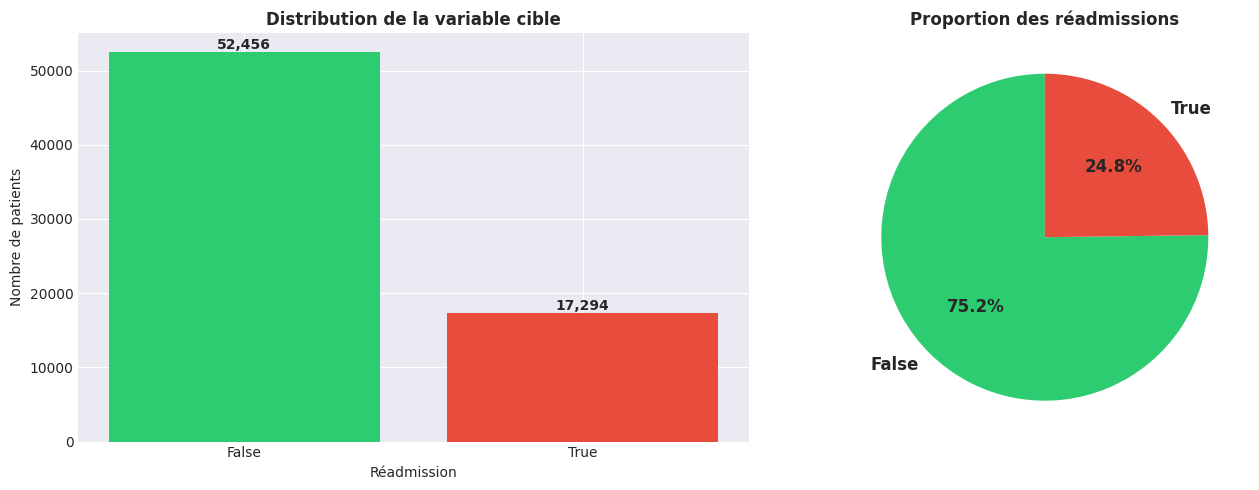

In [0]:
# ========================================
# ANALYSE VARIABLE CIBLE
# ========================================
target_col = 'readmission_30j'
print("="*60)
print(f"ANALYSE VARIABLE CIBLE : {target_col}")
print("="*60)
# Distribution
readmission_counts = df[target_col].value_counts()
readmission_pct = df[target_col].value_counts(normalize=True) * 100
print("\n DISTRIBUTION :")
result = pd.DataFrame({
    'Classe': readmission_counts.index,
    'Fréquence': readmission_counts.values,
    'Pourcentage': readmission_pct.values.round(2)
})
display(result)

# Taux de réadmission
taux_readm = df[target_col].mean()
print(f"\nTaux de réadmission : {taux_readm:.2%}")

# Évaluation déséquilibre
ratio = readmission_counts.max() / readmission_counts.min()
print(f"\n Ratio de déséquilibre : {ratio:.2f}:1")

if ratio > 10:
    print("DÉSÉQUILIBRE SÉVÈRE : Techniques de rééquilibrage obligatoires (SMOTE, class_weight)")
elif ratio > 3:
    print(" DÉSÉQUILIBRE MODÉRÉ : Considérer class_weight ou sous-échantillonnage")
else:
    print("CLASSES RELATIVEMENT ÉQUILIBRÉES")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
axes[0].bar(readmission_counts.index.astype(str), readmission_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_xlabel('Réadmission')
axes[0].set_ylabel('Nombre de patients')
axes[0].set_title('Distribution de la variable cible', fontweight='bold')
for i, v in enumerate(readmission_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(readmission_counts.values, labels=readmission_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proportion des réadmissions', fontweight='bold')

plt.tight_layout()
plt.show()

 DISTRIBUTIONS DES VARIABLES NUMÉRIQUES


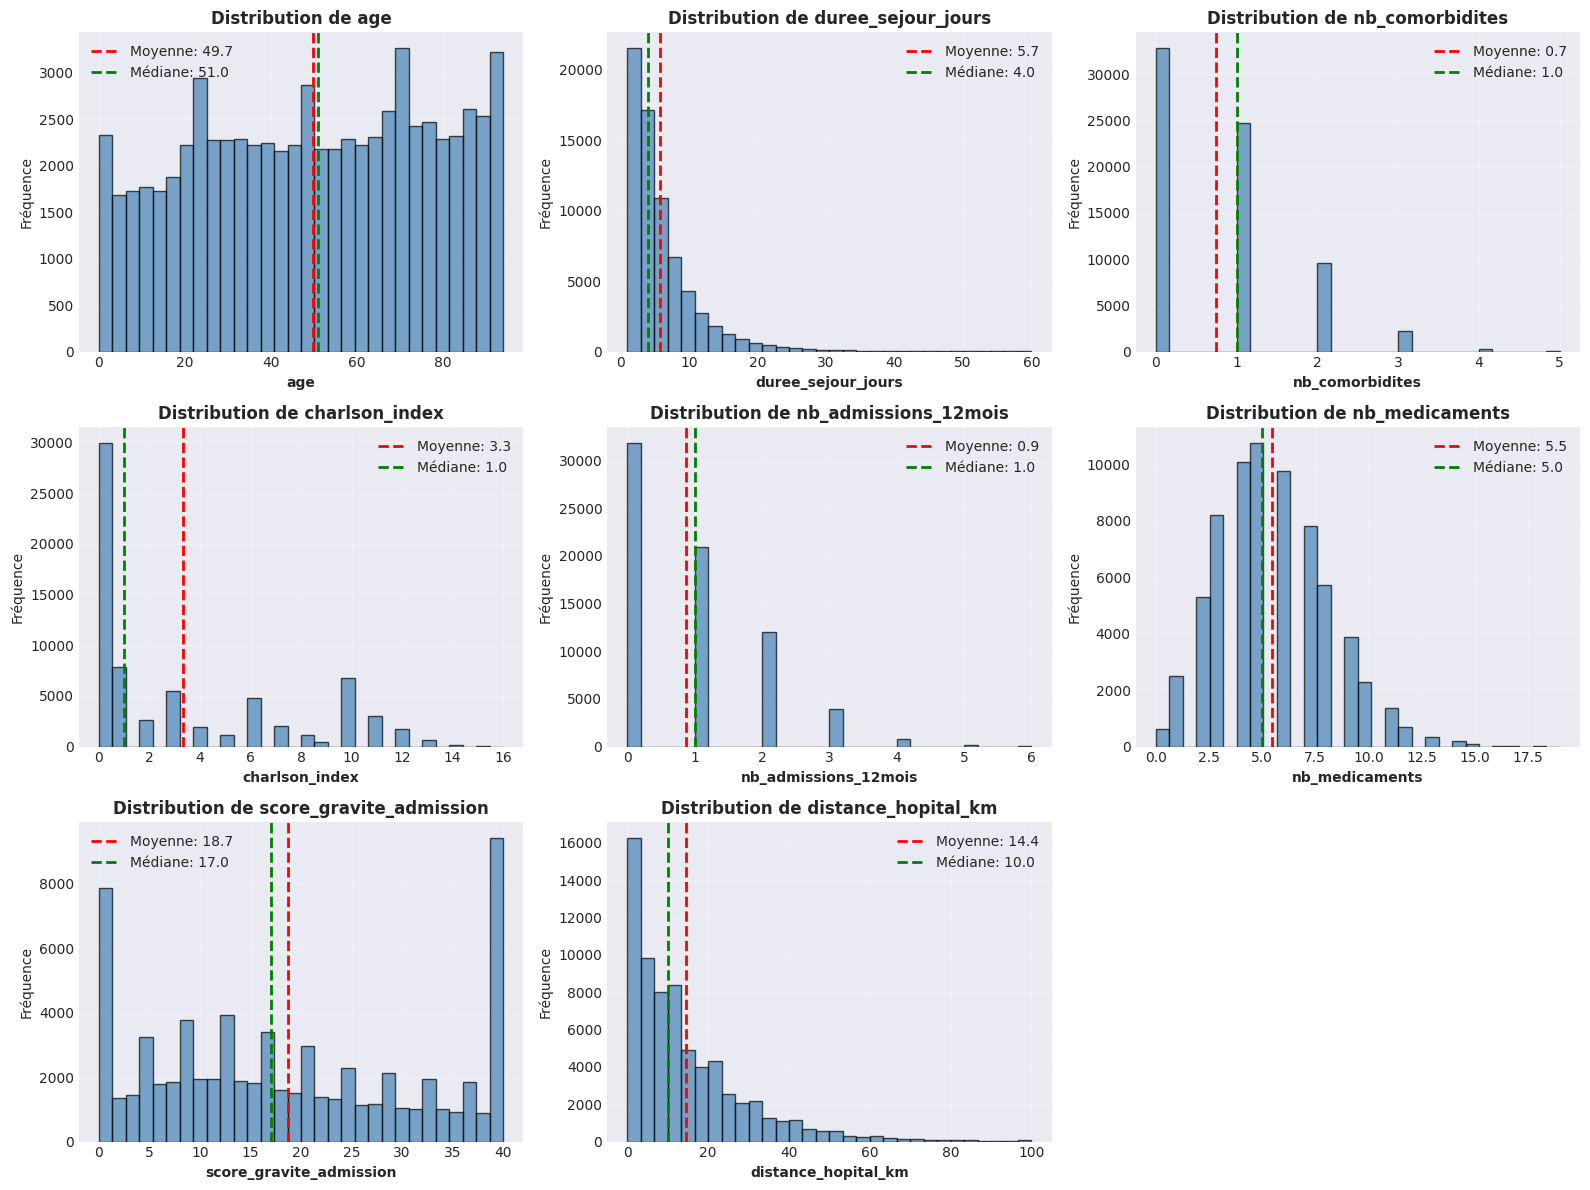


 OBSERVATIONS :
   - Vérifier asymétries (skewness)
   - Identifier outliers potentiels
   - Considérer transformations si nécessaire (log, sqrt)


In [0]:
# ========================================
#  DISTRIBUTIONS VARIABLES NUMÉRIQUES
# ========================================
print("="*60)
print(" DISTRIBUTIONS DES VARIABLES NUMÉRIQUES")
print("="*60)
# Variables numériques continues
num_continuous = ['age', 'duree_sejour_jours', 'nb_comorbidites', 'charlson_index', 
                  'nb_admissions_12mois', 'nb_medicaments', 'score_gravite_admission', 
                  'distance_hopital_km']
# Filtrer colonnes existantes
num_continuous = [col for col in num_continuous if col in df.columns]
# Créer grid de subplots
n_cols = 3
n_rows = int(np.ceil(len(num_continuous) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()
for idx, col in enumerate(num_continuous):
    axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(col, fontweight='bold')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].set_title(f'Distribution de {col}', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    # Ajouter statistiques
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Médiane: {median_val:.1f}')
    axes[idx].legend()
# Masquer subplots vides
for idx in range(len(num_continuous), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.show()
print("\n OBSERVATIONS :")
print("   - Vérifier asymétries (skewness)")
print("   - Identifier outliers potentiels")
print("   - Considérer transformations si nécessaire (log, sqrt)")

DÉTECTION DES OUTLIERS


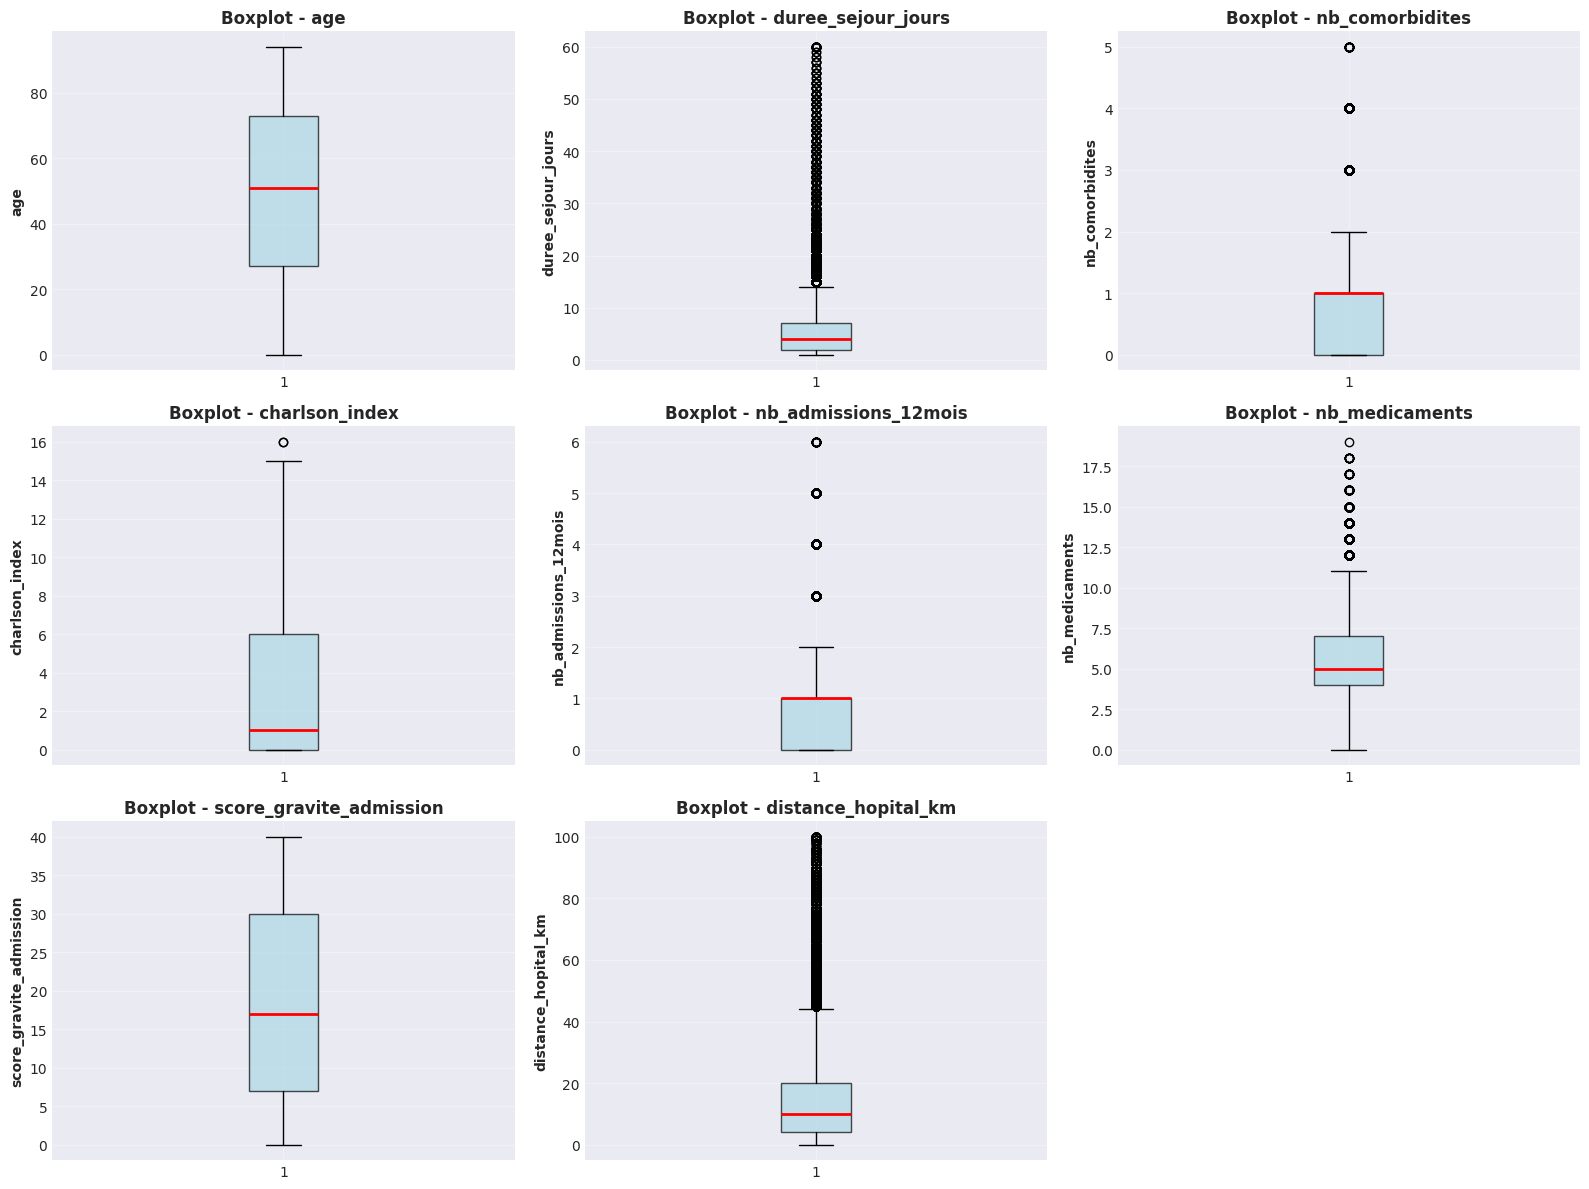


RÉSUMÉ DES OUTLIERS :



Variable,Nb_outliers,Pct_outliers,Min,Max,Borne_inf,Borne_sup
age,0,0.0,0,94,-42.0,142.0
duree_sejour_jours,4653,6.67,1,60,-5.5,14.5
nb_comorbidites,2490,3.57,0,5,-1.5,2.5
charlson_index,2,0.0,0,16,-9.0,15.0
nb_admissions_12mois,4959,7.11,0,6,-1.5,2.5
nb_medicaments,1358,1.95,0,19,-0.5,11.5
score_gravite_admission,0,0.0,0,40,-27.5,64.5
distance_hopital_km,3449,4.94,0,100,-20.0,44.0



 ACTIONS RECOMMANDÉES :
age : 0.0% outliers → Acceptable
 duree_sejour_jours : 6.67% outliers → Considérer traitement
nb_comorbidites : 3.57% outliers → Acceptable
charlson_index : 0.0% outliers → Acceptable
 nb_admissions_12mois : 7.11% outliers → Considérer traitement
nb_medicaments : 1.95% outliers → Acceptable
score_gravite_admission : 0.0% outliers → Acceptable
distance_hopital_km : 4.94% outliers → Acceptable


In [0]:
# ========================================
#  DÉTECTION OUTLIERS (BOXPLOTS)
# ========================================
print("="*60)
print("DÉTECTION DES OUTLIERS")
print("="*60)
# Boxplots pour variables continues
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()
outliers_summary = []
for idx, col in enumerate(num_continuous):
    # Boxplot
    axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
    axes[idx].set_ylabel(col, fontweight='bold')
    axes[idx].set_title(f'Boxplot - {col}', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    # Calcul outliers (IQR method)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    pct_outliers = (len(outliers) / len(df)) * 100
    outliers_summary.append({
        'Variable': col,
        'Nb_outliers': len(outliers),
        'Pct_outliers': round(pct_outliers, 2),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Borne_inf': round(lower_bound, 2),
        'Borne_sup': round(upper_bound, 2)
    })
# Masquer subplots vides
for idx in range(len(num_continuous), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.show()
# Résumé outliers
print("\nRÉSUMÉ DES OUTLIERS :\n")
outliers_df = pd.DataFrame(outliers_summary)
display(outliers_df)

print("\n ACTIONS RECOMMANDÉES :")
for _, row in outliers_df.iterrows():
    if row['Pct_outliers'] > 10:
        print(f" {row['Variable']} : {row['Pct_outliers']}% outliers → Investigation nécessaire")
    elif row['Pct_outliers'] > 5:
        print(f" {row['Variable']} : {row['Pct_outliers']}% outliers → Considérer traitement")
    else:
        print(f"{row['Variable']} : {row['Pct_outliers']}% outliers → Acceptable")

DISTRIBUTIONS PAR RÉADMISSION (OUI/NON)


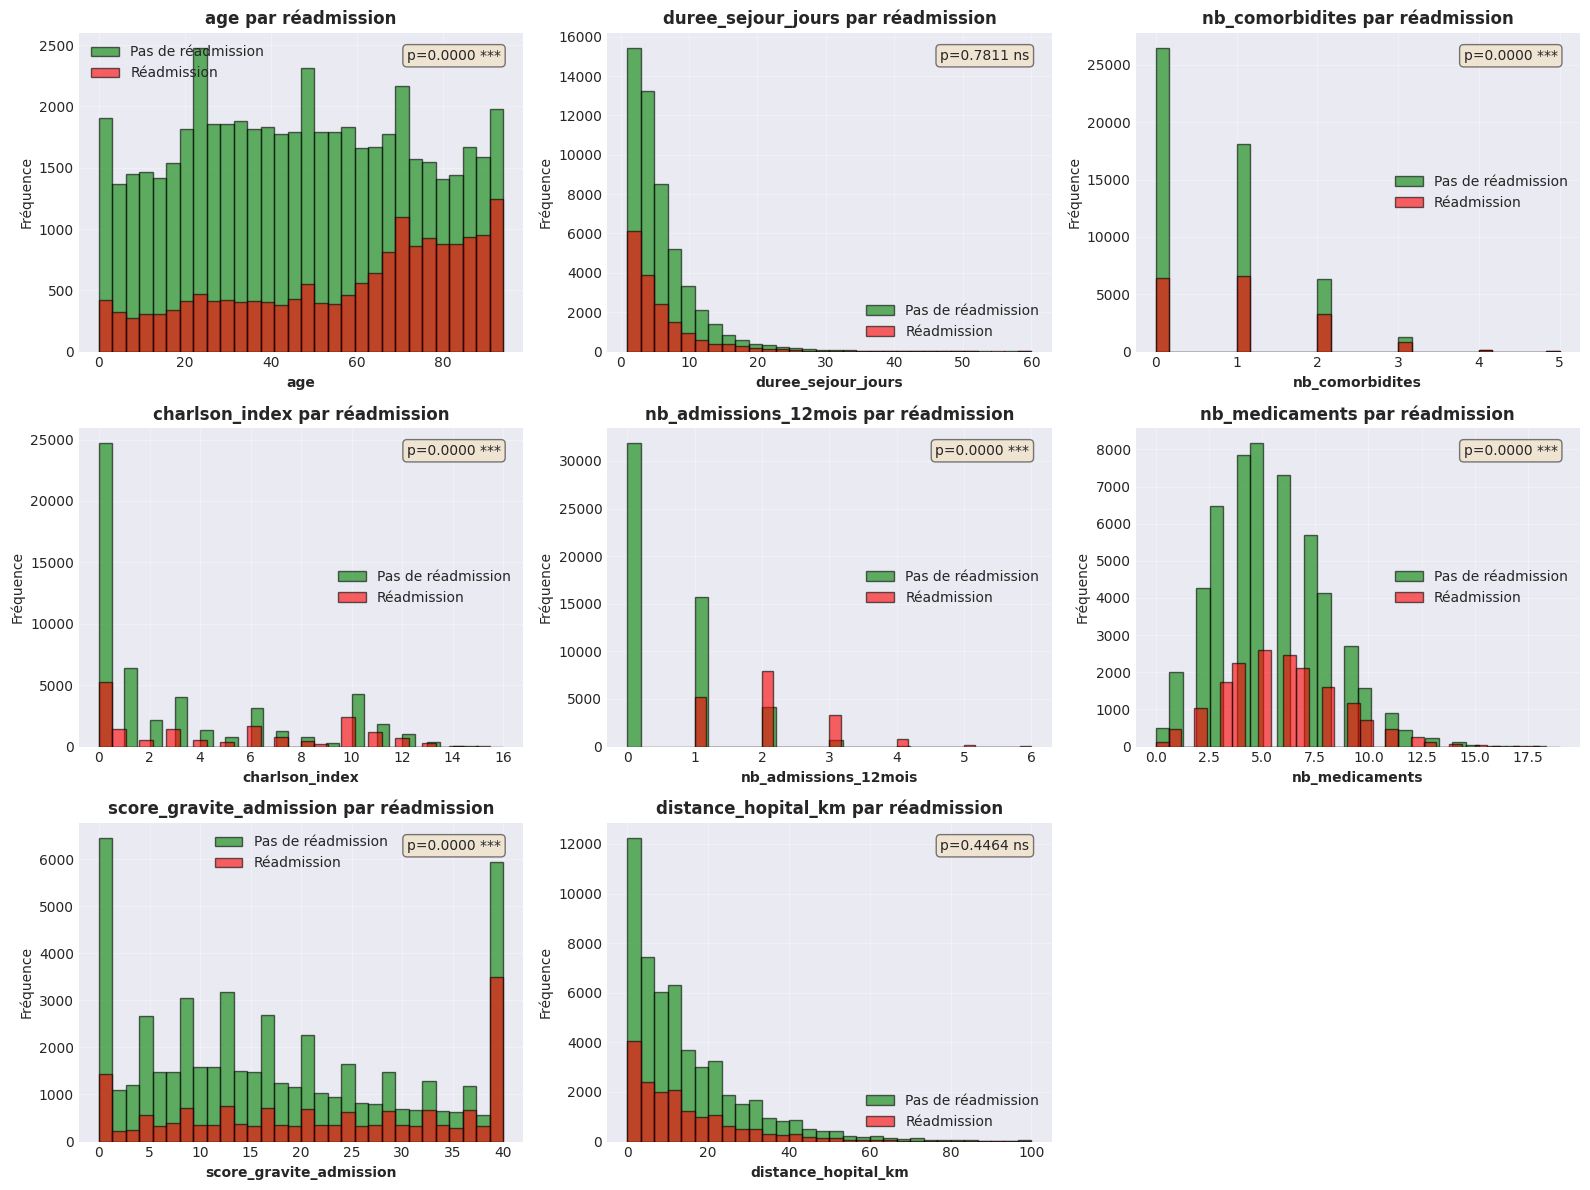


 INTERPRÉTATION :
   *** = Différence hautement significative (p < 0.001)
   **  = Différence très significative (p < 0.01)
   *   = Différence significative (p < 0.05)
   ns  = Non significatif


In [0]:
# ========================================
# DISTRIBUTIONS PAR CLASSE CIBLE
# ========================================
print("="*60)
print("DISTRIBUTIONS PAR RÉADMISSION (OUI/NON)")
print("="*60)
# Comparaison distributions pour chaque variable numérique
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()
for idx, col in enumerate(num_continuous):
    # Séparer par classe
    readm_yes = df[df[target_col] == True][col].dropna()
    readm_no = df[df[target_col] == False][col].dropna()
    # Histogrammes superposés
    axes[idx].hist(readm_no, bins=30, alpha=0.6, label='Pas de réadmission', color='green', edgecolor='black')
    axes[idx].hist(readm_yes, bins=30, alpha=0.6, label='Réadmission', color='red', edgecolor='black')
    axes[idx].set_xlabel(col, fontweight='bold')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].set_title(f'{col} par réadmission', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    # Test statistique (t-test)
    from scipy.stats import ttest_ind
    t_stat, p_value = ttest_ind(readm_yes, readm_no)
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "ns"
    axes[idx].text(0.95, 0.95, f'p={p_value:.4f} {sig}', 
                  transform=axes[idx].transAxes, ha='right', va='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
# Masquer subplots vides
for idx in range(len(num_continuous), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.show()
print("\n INTERPRÉTATION :")
print("   *** = Différence hautement significative (p < 0.001)")
print("   **  = Différence très significative (p < 0.01)")
print("   *   = Différence significative (p < 0.05)")
print("   ns  = Non significatif")

 ANALYSE CATÉGORIELLES VS RÉADMISSION


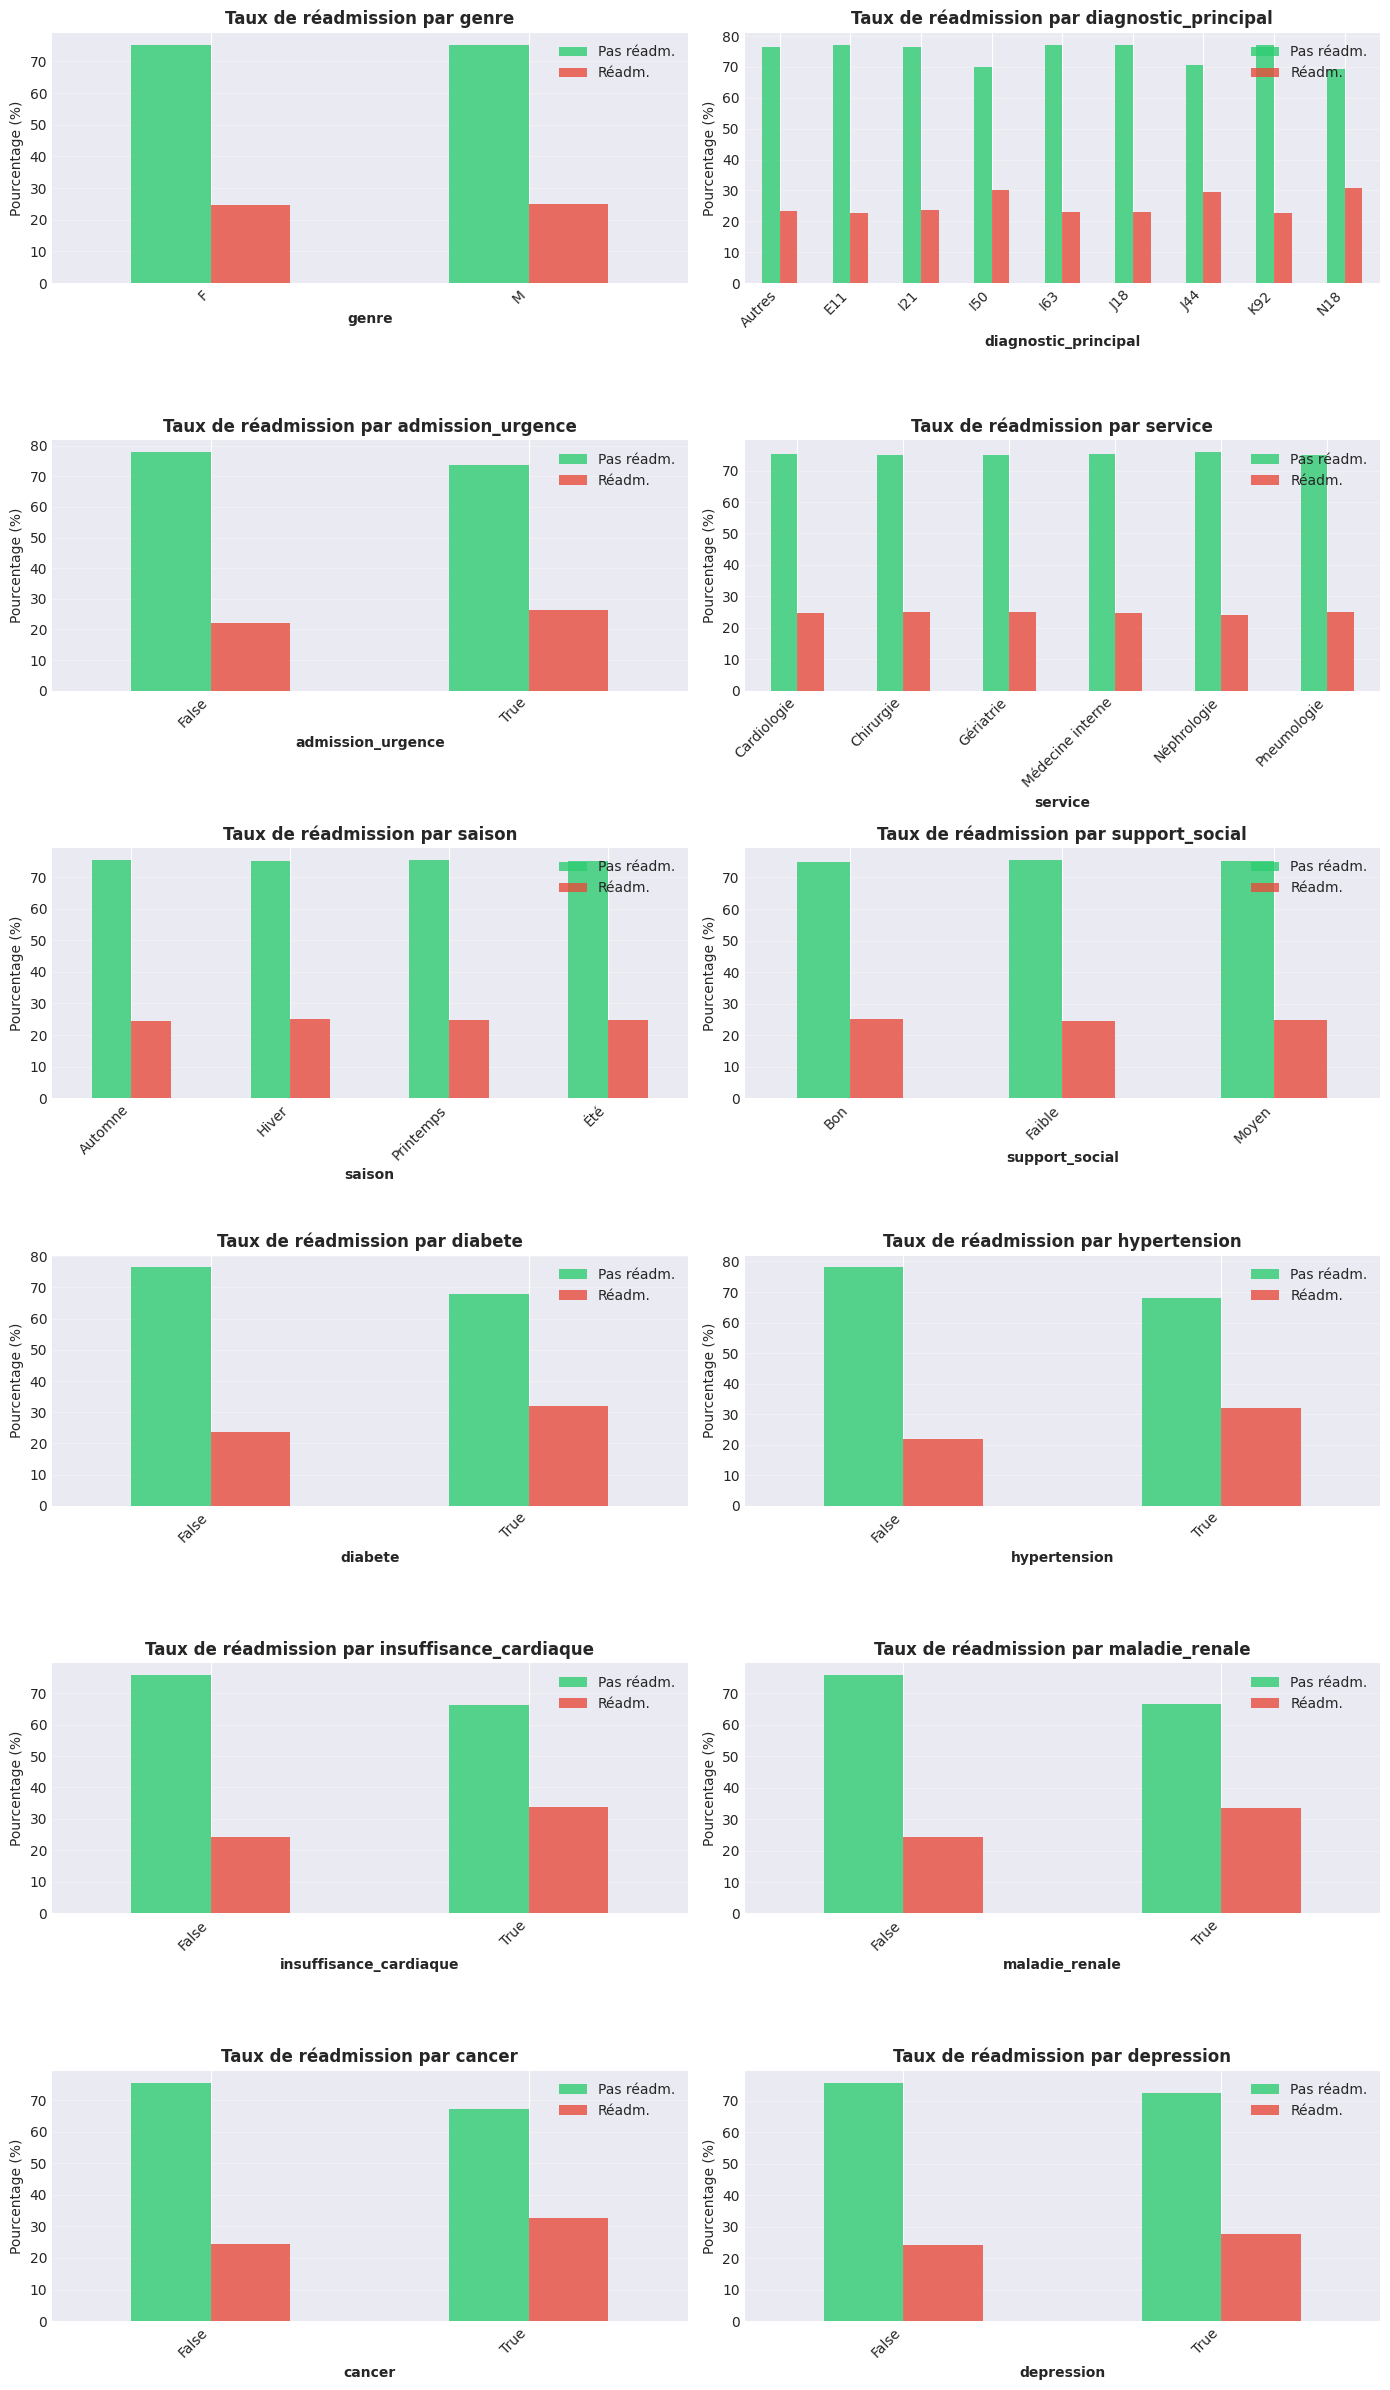


TESTS CHI² (Association avec réadmission) :



Variable,Chi2,p_value,Significatif
genre,0.15,0.6958,Non
diagnostic_principal,308.01,0.0000,Oui
admission_urgence,140.5,0.0000,Oui
service,2.46,0.7826,Non
saison,1.29,0.7306,Non
support_social,2.45,0.2938,Non
diabete,329.66,0.0000,Oui
hypertension,762.8,0.0000,Oui
insuffisance_cardiaque,169.38,0.0000,Oui
maladie_renale,197.53,0.0000,Oui



 VARIABLES SIGNIFICATIVEMENT ASSOCIÉES :
 diagnostic_principal, admission_urgence, diabete, hypertension, insuffisance_cardiaque, maladie_renale, cancer, depression


In [0]:
# ========================================
#  VARIABLES CATÉGORIELLES VS CIBLE
# ========================================
print("="*60)
print(" ANALYSE CATÉGORIELLES VS RÉADMISSION")
print("="*60)
# Variables catégorielles importantes
cat_important = ['genre', 'diagnostic_principal', 'admission_urgence', 'service', 
                 'saison', 'support_social', 'diabete', 'hypertension', 
                 'insuffisance_cardiaque', 'maladie_renale', 'cancer', 'depression']

# Filtrer colonnes existantes
cat_important = [col for col in cat_important if col in df.columns]
# Créer grid
n_cols_cat = 2
n_rows_cat = int(np.ceil(len(cat_important) / n_cols_cat))
fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(14, n_rows_cat*4))
axes = axes.flatten()
chi2_results = []
for idx, col in enumerate(cat_important):
    # Tableau de contingence
    ct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
    # Barplot
    ct.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'], alpha=0.8)
    axes[idx].set_xlabel(col, fontweight='bold')
    axes[idx].set_ylabel('Pourcentage (%)')
    axes[idx].set_title(f'Taux de réadmission par {col}', fontweight='bold')
    axes[idx].legend(['Pas réadm.', 'Réadm.'])
    axes[idx].grid(True, alpha=0.3, axis='y')
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45, ha='right')
    # Test Chi²
    from scipy.stats import chi2_contingency
    ct_raw = pd.crosstab(df[col], df[target_col])
    chi2, p_value, dof, expected = chi2_contingency(ct_raw)
    chi2_results.append({
        'Variable': col,
        'Chi2': round(chi2, 2),
        'p_value': f"{p_value:.4f}",
        'Significatif': 'Oui' if p_value < 0.05 else 'Non'
    })
# Masquer subplots vides
for idx in range(len(cat_important), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.show()
# Résumé tests Chi²
print("\nTESTS CHI² (Association avec réadmission) :\n")
chi2_df = pd.DataFrame(chi2_results)
display(chi2_df)
print("\n VARIABLES SIGNIFICATIVEMENT ASSOCIÉES :")
sig_vars = chi2_df[chi2_df['Significatif'] == 'Oui']['Variable'].tolist()
print(f" {', '.join(sig_vars)}")

ANALYSE DES CORRÉLATIONS


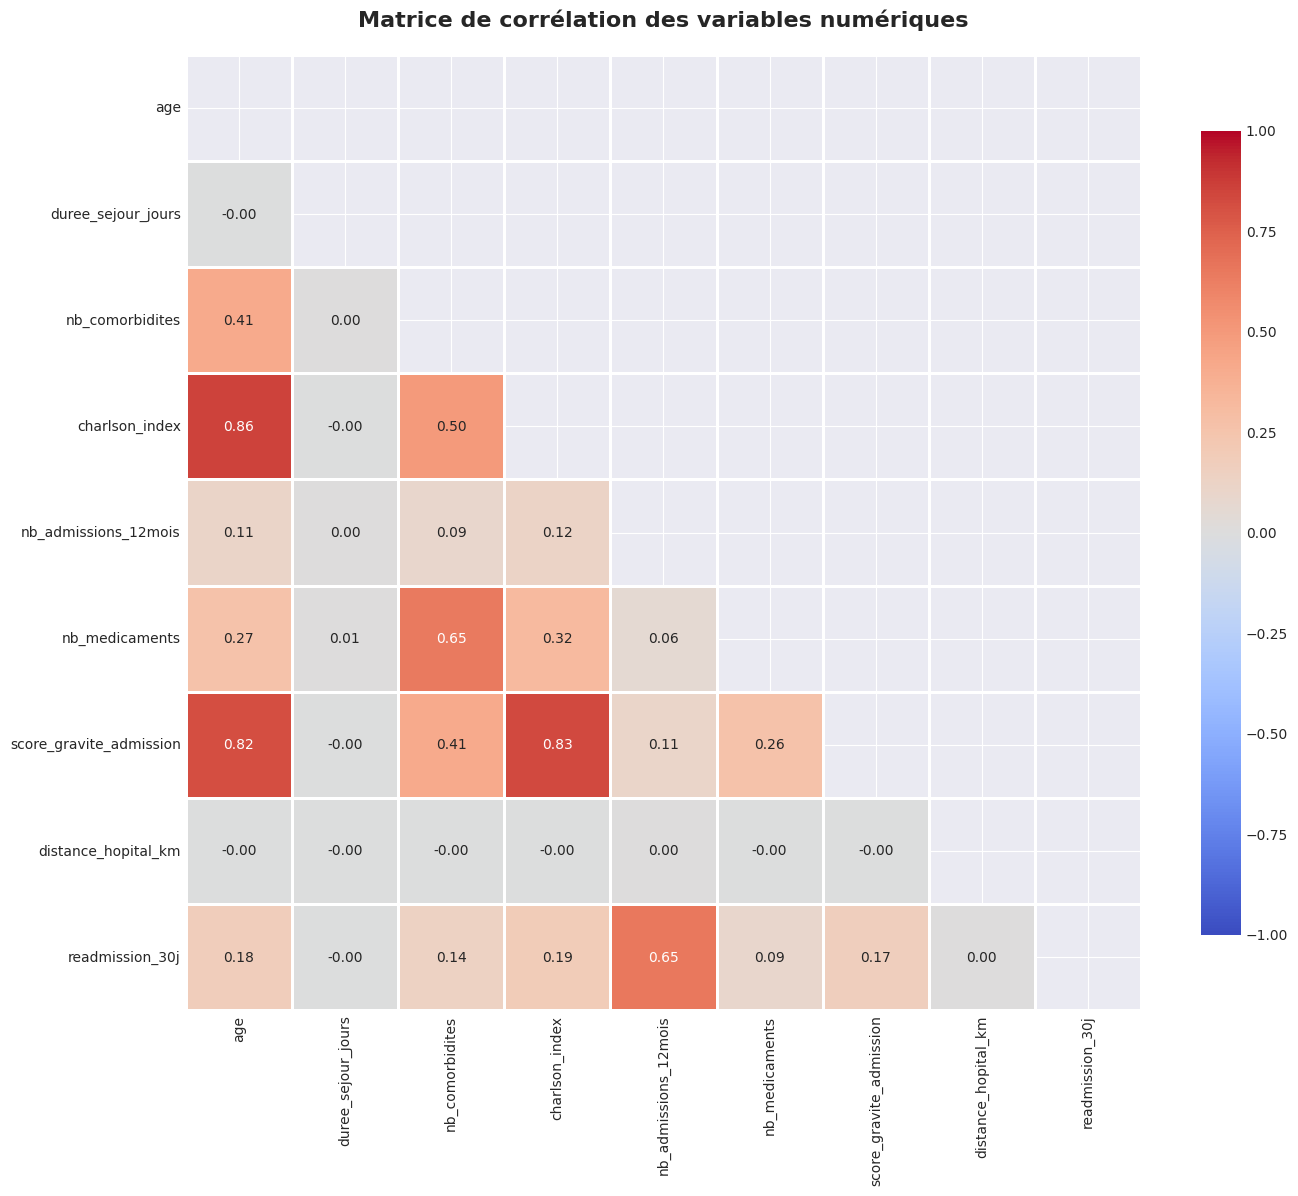


CORRÉLATIONS AVEC LA VARIABLE CIBLE :



---------------------------------------------------------------------------
PySparkValueError                         Traceback (most recent call last)
File <command-7118000662202624>, line 29
     27 print("\nCORRÉLATIONS AVEC LA VARIABLE CIBLE :\n")
     28 target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
---> 29 display(spark.createDataFrame(pd.DataFrame(target_corr, columns=['Corrélation'])))
     30 # Identifier multicolinéarité
     31 print("\n MULTICOLINÉARITÉ DÉTECTÉE (|r| > 0.8) :\n")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/session.py:601, in SparkSession.createDataFrame(self, data, schema, samplingRatio, verifySchema)
    599         return DataFrame(LocalRelation(table=None, schema=_schema.json()), self)
    600     else:
--> 601         raise PySparkValueError(
    602             errorClass="CANNOT_INFER_EMPTY_SCHEMA",
    603             messageParameters={},
    604         )
    606 # Get all related 

In [0]:
# ========================================
#  MATRICE DE CORRÉLATION
# ========================================
print("="*60)
print("ANALYSE DES CORRÉLATIONS")
print("="*60)
# Variables numériques pour corrélation
corr_vars = num_continuous + [target_col]
corr_vars = [col for col in corr_vars if col in df.columns]
# Convertir target en numérique si booléen
df_corr = df[corr_vars].copy()
if df_corr[target_col].dtype == 'bool':
    df_corr[target_col] = df_corr[target_col].astype(int)
# Calcul matrice de corrélation
corr_matrix = df_corr.corr()
# Visualisation
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masquer triangle supérieur
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Matrice de corrélation des variables numériques', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Corrélations avec la cible
print("\nCORRÉLATIONS AVEC LA VARIABLE CIBLE :\n")
target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
display(pd.DataFrame(target_corr, columns=['Corrélation']))
# Identifier multicolinéarité
print("\n MULTICOLINÉARITÉ DÉTECTÉE (|r| > 0.8) :\n")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append({
                'Var1': corr_matrix.columns[i],
                'Var2': corr_matrix.columns[j],
                'Corrélation': round(corr_matrix.iloc[i, j], 3)
            })
if high_corr:
    display(pd.DataFrame(high_corr))
    print("\n ACTION : Considérer suppression d'une des deux variables corrélées")
else:
    print("Pas de multicolinéarité sévère détectée")

ANALYSE TEMPORELLE


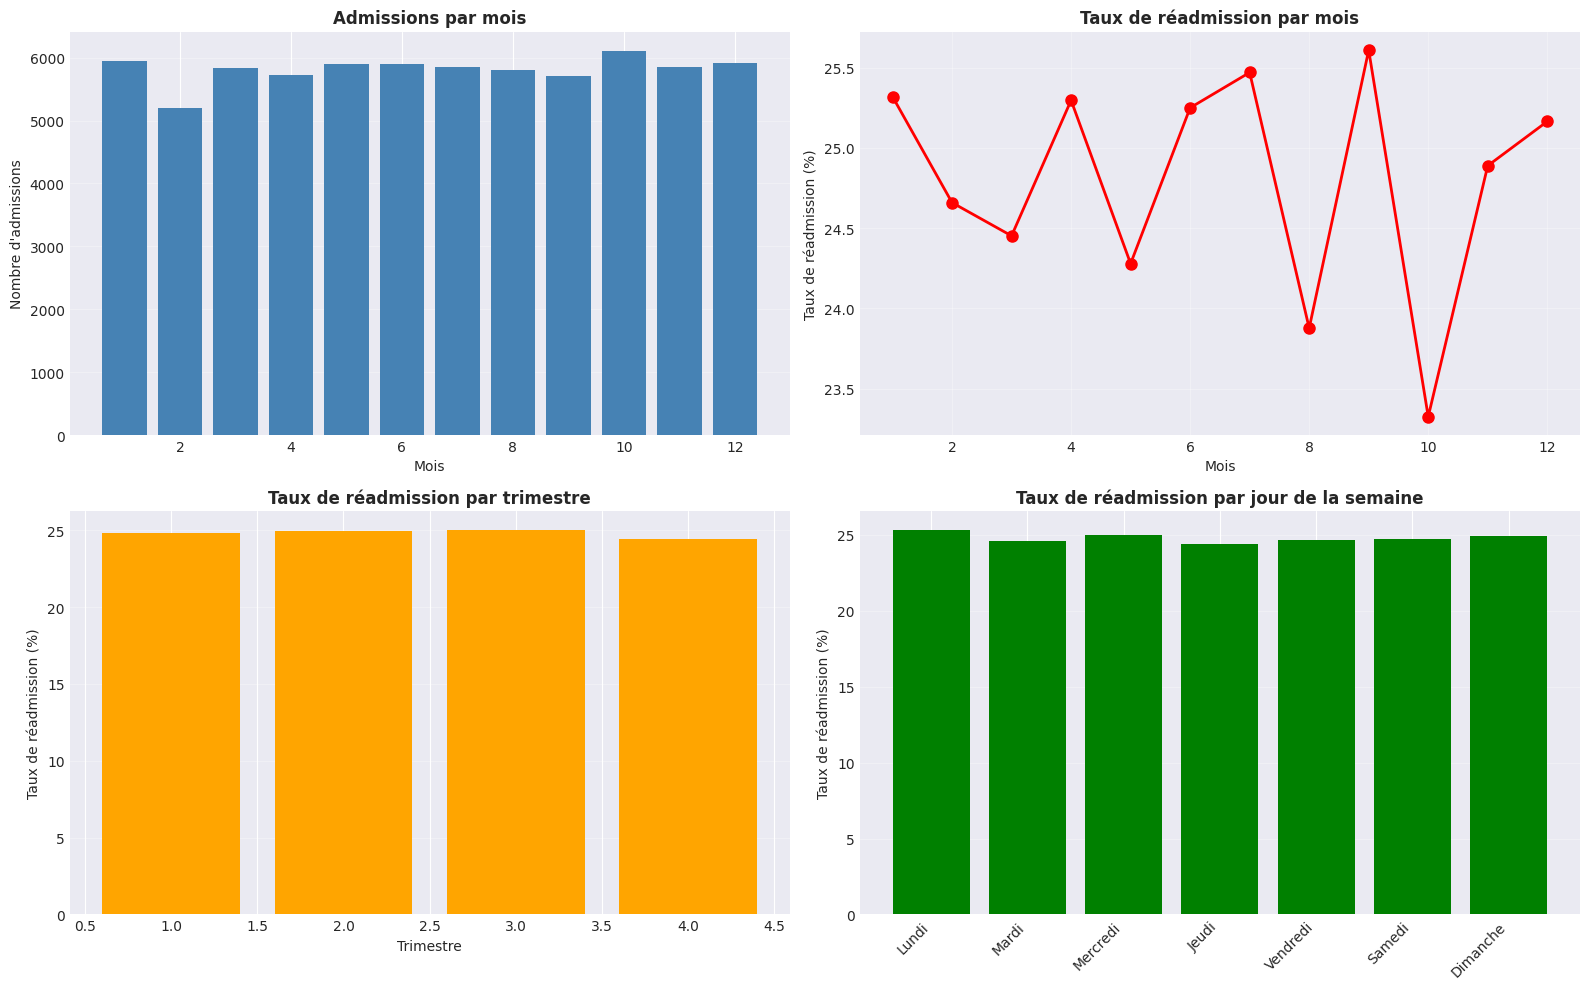


OBSERVATIONS :
 - Mois avec le plus d'admissions : Mois 10
 - Mois avec taux réadmission max : Mois 9 (25.6%)
   - Variation saisonnière : Non


In [0]:
# ========================================
# ANALYSE TEMPORELLE
# ========================================

if 'date_admission' in df.columns:
    print("="*60)
    print("ANALYSE TEMPORELLE")
    print("="*60)
    # Convertir en datetime
    df['date_admission'] = pd.to_datetime(df['date_admission'])
    df['mois'] = df['date_admission'].dt.month
    df['trimestre'] = df['date_admission'].dt.quarter
    df['jour_semaine'] = df['date_admission'].dt.dayofweek
    # Admissions par mois
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    # Par mois
    monthly_counts = df.groupby('mois').size()
    axes[0, 0].bar(monthly_counts.index, monthly_counts.values, color='steelblue')
    axes[0, 0].set_xlabel('Mois')
    axes[0, 0].set_ylabel('Nombre d\'admissions')
    axes[0, 0].set_title('Admissions par mois', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    # Réadmissions par mois
    monthly_readm = df.groupby('mois')[target_col].mean() * 100
    axes[0, 1].plot(monthly_readm.index, monthly_readm.values, marker='o', linewidth=2, markersize=8, color='red')
    axes[0, 1].set_xlabel('Mois')
    axes[0, 1].set_ylabel('Taux de réadmission (%)')
    axes[0, 1].set_title('Taux de réadmission par mois', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    # Par trimestre
    quarterly_readm = df.groupby('trimestre')[target_col].mean() * 100
    axes[1, 0].bar(quarterly_readm.index, quarterly_readm.values, color='orange')
    axes[1, 0].set_xlabel('Trimestre')
    axes[1, 0].set_ylabel('Taux de réadmission (%)')
    axes[1, 0].set_title('Taux de réadmission par trimestre', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    # Par jour de la semaine
    jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
    dow_readm = df.groupby('jour_semaine')[target_col].mean() * 100
    axes[1, 1].bar(range(7), dow_readm.values, color='green')
    axes[1, 1].set_xticks(range(7))
    axes[1, 1].set_xticklabels(jours, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Taux de réadmission (%)')
    axes[1, 1].set_title('Taux de réadmission par jour de la semaine', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    print("\nOBSERVATIONS :")
    print(f" - Mois avec le plus d'admissions : Mois {monthly_counts.idxmax()}")
    print(f" - Mois avec taux réadmission max : Mois {monthly_readm.idxmax()} ({monthly_readm.max():.1f}%)")
    print(f"   - Variation saisonnière : {'Oui' if monthly_readm.std() > 2 else 'Non'}")
else:
    print("Variable 'date_admission' non trouvée. Analyse temporelle ignorée.")

In [0]:
# ========================================
# PROFILS PATIENTS À RISQUE
# ========================================
print("="*60)
print("PROFILS DES PATIENTS RÉADMIS")
print("="*60)
# Comparaison moyennes
readm_yes = df[df[target_col] == True]
readm_no = df[df[target_col] == False]
comparison_df = pd.DataFrame({
    'Variable': num_continuous,
    'Moyenne_Réadmis': [readm_yes[col].mean() for col in num_continuous],
    'Moyenne_Non_Réadmis': [readm_no[col].mean() for col in num_continuous],
})
comparison_df['Différence (%)'] = ((comparison_df['Moyenne_Réadmis'] - comparison_df['Moyenne_Non_Réadmis']) / 
                                   comparison_df['Moyenne_Non_Réadmis'] * 100).round(2)
comparison_df = comparison_df.sort_values('Différence (%)', ascending=False)
display(comparison_df)
print("\n INSIGHTS CLÉS :")
print("\nFacteurs de risque principaux (différence > 20%) :")
high_risk = comparison_df[comparison_df['Différence (%)'] > 20]
for _, row in high_risk.iterrows():
    print(f"   ✓ {row['Variable']} : +{row['Différence (%)']:.1f}% chez patients réadmis")
# Visualisation radar chart des

PROFILS DES PATIENTS RÉADMIS


Variable,Moyenne_Réadmis,Moyenne_Non_Réadmis,Différence (%)
nb_admissions_12mois,2.005377587602637,0.5009341162116822,300.33
charlson_index,4.71169191627154,2.861560164709471,64.65
nb_comorbidites,0.9413669480744767,0.6765479640079305,39.14
score_gravite_admission,22.51150688099919,17.42488943114229,29.19
age,57.91199259858911,46.96595241726399,23.31
nb_medicaments,5.887764542615936,5.338817294494434,10.28
distance_hopital_km,14.52422805597317,14.424736922373036,0.69
duree_sejour_jours,5.694691800624494,5.708727314320574,-0.25



 INSIGHTS CLÉS :

Facteurs de risque principaux (différence > 20%) :
   ✓ nb_admissions_12mois : +300.3% chez patients réadmis
   ✓ charlson_index : +64.7% chez patients réadmis
   ✓ nb_comorbidites : +39.1% chez patients réadmis
   ✓ score_gravite_admission : +29.2% chez patients réadmis
   ✓ age : +23.3% chez patients réadmis
